# Optativa III: Ciencia de Datos
## Revisión técnica de alto nivel — Limpieza + análisis estadístico del dataset de Amazon

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 4 · Actividad integradora avanzada**

---

### Propósito

Esta actividad de **nivel avanzado** integra la limpieza de datos (Semana 4) con todo el análisis estadístico visto en el curso (Semanas 2 y 3), sobre una versión **cruda y sucia** del dataset real de **Amazon**. Aquí no recibirás datos limpios: primero deberás **procesarlos** y luego ejecutar un **análisis estadístico completo** (descriptivo, inferencial, correlación y regresión) sobre datos que tú mismo depuraste.

Este es el flujo real de un científico de datos: **datos crudos → limpieza → análisis → interpretación**.

Responderás **50 preguntas ✍️** de análisis y de modificación de código, con un nivel de complejidad alto.

### El dataset

`amazon_raw.csv` — versión cruda del Amazon Sales Dataset (~1,480 filas) con problemas reales: precios como texto con símbolo `₹` y comas, porcentajes con `%`, calificaciones corruptas (`|`), conteos con comas, nulos y duplicados. Súbelo a Colab antes de empezar.

### Cómo trabajar

Ejecuta cada celda en orden con **Shift + Enter**, responde las preguntas ✍️, completa los retos y entrega en Classroom. El nivel es alto: tómate tu tiempo para interpretar, no solo ejecutar.


---
# FASE 1 — Diagnóstico y limpieza (Semana 4)

## Paso 0 — Carga y auditoría inicial


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
np.random.seed(42)

df = pd.read_csv("amazon_raw - amazon_raw.csv")
print("Dimensiones crudas:", df.shape)
df.head()

Dimensiones crudas: (1480, 8)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,B0416836764,Producto Computers&Accessories 0,Computers&Accessories,₹874,"₹4,163",79%,4.1,"8,922"
1,B0490841834,Producto Car&Motorbike 1,Car&Motorbike,₹510,"₹1,021",50%,|,"13,556"
2,B0128388400,Producto Home&Kitchen 2,Home&Kitchen,"₹1,128","₹1,880",40%,3.2,"1,326"
3,B0269299842,Producto Computers&Accessories 3,Computers&Accessories,"₹1,301","₹2,711",52%,3.7,"5,65"
4,B0199799663,Producto Electronics 4,Electronics,"₹4,168","₹6,833",39%,4.1,"3,386"


In [3]:
# Auditoria de calidad
print("=== TIPOS DE DATOS ===")
print(df.dtypes)
print("\n=== NULOS ===")
print(df.isnull().sum())
print("\n=== DUPLICADOS ===", df.duplicated().sum())

=== TIPOS DE DATOS ===
product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
dtype: object

=== NULOS ===
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           5
dtype: int64

=== DUPLICADOS === 15


> ✍️ **1.** Observa `df.dtypes`. ¿Por qué columnas como `actual_price` o `rating_count` aparecen como `object` (texto) en lugar de números? Da la razón específica mirando sus valores.

> ✍️ **2.** ¿Cuántos duplicados y cuántos nulos hay en total? ¿En qué columnas?

> ✍️ **3.** La columna `rating` tiene un valor corrupto: `"|"`. ¿Cómo crees que un carácter así llega a un dataset real? (Piensa en errores de scraping o de captura.)

> ✍️ **4.** Antes de limpiar, ¿podrías calcular el precio promedio con `df["actual_price"].mean()`? ¿Por qué no? Explica el tipo de error que daría.


## Paso 1 — Eliminar duplicados


In [4]:
antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Eliminados {antes - len(df)} duplicados. Filas: {len(df)}")

Eliminados 15 duplicados. Filas: 1465


> ✍️ **5.** ¿Cuántos duplicados se eliminaron? ¿Por qué conviene eliminar duplicados ANTES de convertir tipos y analizar?


## Paso 2 — Convertir precios de texto a número

Los precios tienen el símbolo `₹` (rupia) y comas de miles: `"₹1,128"`. Hay que limpiarlos.


In [5]:
print("Valores crudos de ejemplo:", df["actual_price"].head(3).tolist())

# Limpieza de columnas de precio
for col in ["discounted_price", "actual_price"]:
    df[col] = (df[col]
               .astype(str)
               .str.replace("₹", "", regex=False)
               .str.replace(",", "", regex=False)
               .str.strip())
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nDespues de limpiar:")
print(df[["discounted_price", "actual_price"]].head(3))
print("\nTipos:", df["actual_price"].dtype)
print("Precio real promedio: ₹", round(df["actual_price"].mean(), 2))

Valores crudos de ejemplo: ['₹4,163', '₹1,021', '₹1,880']

Despues de limpiar:
   discounted_price  actual_price
0               874          4163
1               510          1021
2              1128          1880

Tipos: int64
Precio real promedio: ₹ 2565.81


> ✍️ **6.** Explica cada paso de la cadena de limpieza: `.str.replace("₹","")`, `.str.replace(",","")`, `pd.to_numeric(..., errors="coerce")`.

> ✍️ **7.** Ahora sí, ¿cuál es el precio real (`actual_price`) promedio? ¿Y el precio con descuento promedio?

> ✍️ **8.** ¿Por qué las comas de miles impiden que pandas reconozca `"1,128"` como el número 1128? ¿Qué interpretaría Python si intentara convertirlo directamente?


### 🔧 Reto 1 — Verifica una columna limpiada por ti

Aún queda por convertir la columna `discount_percentage` (tiene valores como `"79%"`), pero en el Paso 3 la limpiaremos junto con el rating. Como reto, escribe TÚ el código que quitaría el `%` y la convertiría a número, y muestra su `describe()`. Compara tu resultado con el de la celda del Paso 3.


In [7]:
copia = pd.read_csv("amazon_raw - amazon_raw.csv")["discount_percentage"]
copia = pd.to_numeric(copia.astype(str).str.replace("%","",regex=False), errors="coerce")
print(copia.describe())

count    1480.000000
mean       45.172297
std        15.441816
min         4.000000
25%        34.000000
50%        45.000000
75%        57.000000
max        85.000000
Name: discount_percentage, dtype: float64


> ✍️ **9.** Tras limpiar `discount_percentage` (ver Paso 3), ¿cuál es el porcentaje de descuento promedio y el máximo? ¿Los descuentos de Amazon son en general altos o bajos?


## Paso 3 — Limpiar rating y rating_count


In [8]:
# discount_percentage: quitar el simbolo % y convertir (lo necesitamos ya)
df["discount_percentage"] = (df["discount_percentage"]
                             .astype(str)
                             .str.replace("%", "", regex=False))
df["discount_percentage"] = pd.to_numeric(df["discount_percentage"], errors="coerce")

# rating tiene valores corruptos "|": los convertimos a NaN con coerce
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# rating_count tiene comas de miles
df["rating_count"] = (df["rating_count"]
                      .astype(str)
                      .str.replace(",", "", regex=False))
df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

print("Nulos tras conversion:")
print(df[["rating", "rating_count"]].isnull().sum())
print("\nRating promedio:", round(df["rating"].mean(), 3))

Nulos tras conversion:
rating          19
rating_count     5
dtype: int64

Rating promedio: 4.004


> ✍️ **10.** ¿Cuántos valores nulos aparecieron en `rating` tras la conversión? ¿De dónde salieron? (Pista: los `"|"` corruptos.)

> ✍️ **11.** ¿Qué estrategia usarías para los nulos de `rating`: eliminarlos o imputarlos? Considera que son pocos (~2%). Justifica.


In [9]:
# Decidimos imputar los pocos nulos de rating con la mediana
df["rating"] = df["rating"].fillna(df["rating"].median())
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())
print("Nulos restantes en rating:", df["rating"].isnull().sum())

Nulos restantes en rating: 0


> ✍️ **12.** ¿Por qué la mediana es preferible a la media para imputar `rating_count`, que suele tener valores extremos (productos virales con cientos de miles de reseñas)?


## Paso 4 — Validación con reglas de negocio

Verificamos que los datos limpios cumplan reglas lógicas: el rating debe estar entre 1 y 5, el descuento entre 0 y 100, y el precio con descuento no puede superar al precio real.


In [10]:
# Regla 1: rating en [1, 5]
fuera_rating = ((df["rating"] < 1) | (df["rating"] > 5)).sum()
# Regla 2: descuento en [0, 100]
fuera_desc = ((df["discount_percentage"] < 0) | (df["discount_percentage"] > 100)).sum()
# Regla 3: precio con descuento <= precio real
incoherentes = (df["discounted_price"] > df["actual_price"]).sum()

print(f"Ratings fuera de [1,5]:          {fuera_rating}")
print(f"Descuentos fuera de [0,100]:     {fuera_desc}")
print(f"Descuento > precio real (error): {incoherentes}")

Ratings fuera de [1,5]:          0
Descuentos fuera de [0,100]:     0
Descuento > precio real (error): 0


> ✍️ **13.** ¿Los datos cumplen las tres reglas de negocio? ¿Por qué la validación con reglas es un paso distinto de la limpieza de formato?

> ✍️ **14.** Propón **dos reglas de negocio adicionales** que tendrían sentido para este dataset de productos (por ejemplo, sobre `rating_count` o `actual_price`).


## Paso 5 — Detección de outliers


Q1=928  Q3=3438  IQR=2510
Limite superior: 7203
Outliers en actual_price: 78 (5.3%)


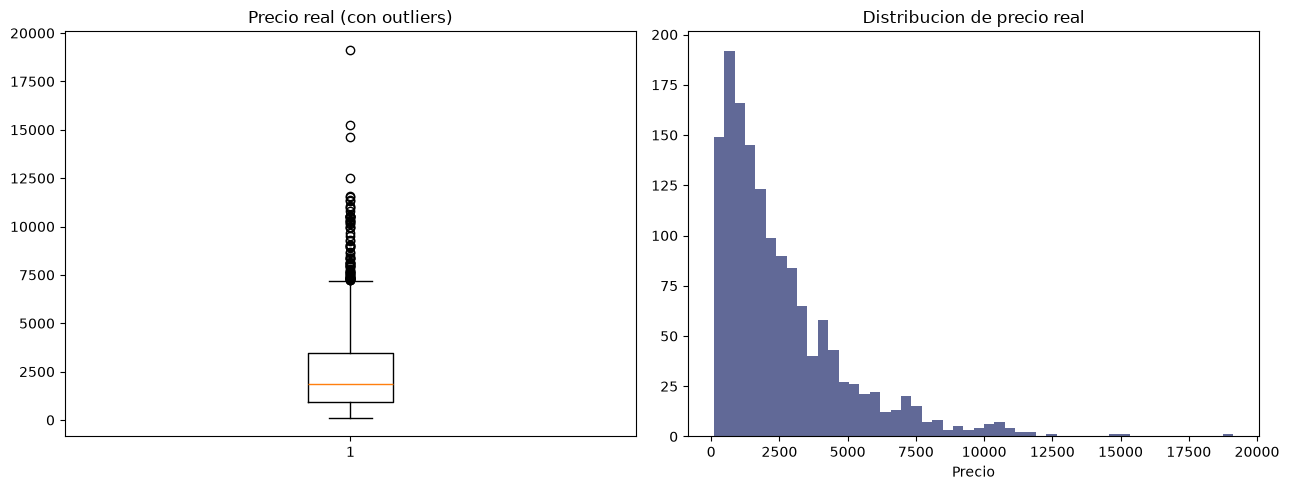

In [11]:
# Outliers en actual_price con el metodo IQR
Q1, Q3 = df["actual_price"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
outliers = (df["actual_price"] > lim_sup).sum()

print(f"Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}")
print(f"Limite superior: {lim_sup:.0f}")
print(f"Outliers en actual_price: {outliers} ({outliers/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].boxplot(df["actual_price"]); axes[0].set_title("Precio real (con outliers)")
axes[1].hist(df["actual_price"], bins=50, color="#1e2a6b", alpha=0.7)
axes[1].set_title("Distribucion de precio real"); axes[1].set_xlabel("Precio")
plt.tight_layout(); plt.show()

> ✍️ **15.** ¿Cuántos outliers de precio detectó el método IQR? ¿Qué porcentaje del total representan?

> ✍️ **16.** Mira el histograma: ¿la distribución de precios es simétrica o sesgada? ¿Hacia qué lado? ¿Cómo se relaciona esto con la cantidad de outliers por el lado derecho?

> ✍️ **17.** En este caso, ¿eliminarías los outliers de precio o los conservarías? Argumenta: un producto de precio muy alto, ¿es un error o un producto premium legítimo?


### 🔧 Reto 2 — Crear variable de ahorro

Crea una columna `ahorro` = `actual_price` − `discounted_price`, y una columna `ahorro_pct` que sea el ahorro como porcentaje del precio real. Verifica que `ahorro_pct` sea coherente con `discount_percentage`.


In [12]:
df["ahorro"] = df["actual_price"] - df["discounted_price"]
df["ahorro_pct"] = (df["ahorro"] / df["actual_price"] * 100).round(1)
print(df[["discount_percentage", "ahorro_pct"]].head())

   discount_percentage  ahorro_pct
0                   79        79.0
1                   50        50.0
2                   40        40.0
3                   52        52.0
4                   39        39.0


> ✍️ **18.** ¿La columna `ahorro_pct` que calculaste coincide aproximadamente con `discount_percentage`? Si hay pequeñas diferencias, ¿a qué se deben (redondeos)?

> ✍️ **19.** ¿Cuál es el ahorro promedio en rupias que ofrece Amazon en este dataset? ¿Y el producto con mayor ahorro absoluto?


---
# FASE 2 — Estadística descriptiva e inferencial (Semana 2)

## Paso 6 — Estadística descriptiva sobre datos limpios


In [13]:
print("Estadisticas descriptivas (datos limpios):")
df[["actual_price", "discounted_price", "discount_percentage", "rating", "rating_count"]].describe()

Estadisticas descriptivas (datos limpios):


,actual_price,discounted_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000
mean,2565.808191,1410.845051,45.092833,4.003891,5048.304437
std,2291.867873,1375.484899,15.454308,0.273197,4750.111757
min,100.000000,42.000000,4.000000,3.100000,4.000000
25%,928.000000,483.000000,33.000000,3.800000,1625.000000
50%,1856.000000,980.000000,45.000000,4.000000,3689.000000
75%,3438.000000,1856.000000,57.000000,4.200000,6982.000000
max,19137.000000,11686.000000,85.000000,4.900000,39263.000000


> ✍️ **20.** Para `actual_price`: compara media y mediana. ¿Qué indica la diferencia sobre el sesgo? ¿Qué medida reportarías como "precio típico"?

> ✍️ **21.** ¿Cuál es la desviación estándar del `rating`? ¿Los productos de Amazon tienen calificaciones muy dispersas o concentradas alrededor de la media?

> ✍️ **22.** El coeficiente de variación (desviación/media) permite comparar dispersión entre variables de distinta escala. Calcula el CV de `actual_price` y de `rating` en una celda. ¿Cuál varía relativamente más?


In [ ]:
# Celda para la P22: coeficiente de variacion
# cv_precio = df["actual_price"].std() / df["actual_price"].mean()
# cv_rating = df["rating"].std() / df["rating"].mean()
# print(f"CV precio: {cv_precio:.3f}   CV rating: {cv_rating:.3f}")


## Paso 7 — Intervalo de confianza


In [14]:
n = len(df)
media_r = df["rating"].mean()
ee = df["rating"].std(ddof=1) / np.sqrt(n)
ic95 = stats.t.interval(0.95, df=n-1, loc=media_r, scale=ee)
print(f"Rating promedio: {media_r:.3f}")
print(f"IC 95%: ({ic95[0]:.3f}, {ic95[1]:.3f})")

Rating promedio: 4.004
IC 95%: (3.990, 4.018)


> ✍️ **23.** Interpreta el intervalo de confianza del rating. ¿Es estrecho? ¿Qué papel juega el tamaño de muestra?

> ✍️ **24.** Modifica el código para un IC al 90% y otro al 99%. Ordena los tres intervalos (90%, 95%, 99%) de más estrecho a más ancho y explica la relación entre confianza y amplitud.


In [15]:
# Celda para la P24: IC al 90% y 99%
# ic90 = stats.t.interval(0.90, df=n-1, loc=media_r, scale=ee)
# ic99 = stats.t.interval(0.99, df=n-1, loc=media_r, scale=ee)
# print("90%:", ic90); print("99%:", ic99)


## Paso 8 — Probabilidad condicional y Bayes


In [16]:
# Definimos eventos
df["CARO"] = df["actual_price"] >= df["actual_price"].quantile(0.75)
df["ALTO_DESC"] = df["discount_percentage"] >= 50

P_alto_desc = df["ALTO_DESC"].mean()
P_alto_desc_dado_caro = df[df["CARO"]]["ALTO_DESC"].mean()

print(f"P(descuento alto)              = {P_alto_desc:.3f}")
print(f"P(descuento alto | producto caro) = {P_alto_desc_dado_caro:.3f}")

# Bayes
P_caro = df["CARO"].mean()
P_caro_dado_alto = (P_alto_desc_dado_caro * P_caro) / P_alto_desc
print(f"P(caro | descuento alto) via Bayes = {P_caro_dado_alto:.3f}")
print(f"Verificacion directa               = {df[df['ALTO_DESC']]['CARO'].mean():.3f}")

P(descuento alto)              = 0.405
P(descuento alto | producto caro) = 0.428
P(caro | descuento alto) via Bayes = 0.265
Verificacion directa               = 0.265


> ✍️ **25.** ¿Los productos caros tienen más probabilidad de tener descuentos altos? Compara P(descuento alto | caro) con P(descuento alto).

> ✍️ **26.** Verifica que Bayes coincida con el cálculo directo. Explica qué representa P(caro | descuento alto) en términos de negocio.

> ✍️ **27.** ¿Por qué P(descuento alto | caro) y P(caro | descuento alto) son distintas? (La condicional transpuesta de la Semana 2.)


---
# FASE 3 — Pruebas de hipótesis (Semana 3)

## Paso 9 — Prueba t y ANOVA


In [17]:
# Prueba t: rating de productos caros vs baratos
caros = df[df["CARO"]]["rating"]
baratos = df[~df["CARO"]]["rating"]
t_stat, p_t = stats.ttest_ind(caros, baratos, equal_var=False)
print(f"Prueba t (rating caros vs baratos):")
print(f"  rating caros={caros.mean():.3f}  baratos={baratos.mean():.3f}")
print(f"  t={t_stat:.3f}  p={p_t:.4f}  ->  {'significativo' if p_t<0.05 else 'NO significativo'}")

# ANOVA: rating por categoria (top 4)
top4 = df["category"].value_counts().head(4).index
grupos = [df[df["category"]==c]["rating"] for c in top4]
F, p_anova = stats.f_oneway(*grupos)
print(f"\nANOVA (rating por categoria): F={F:.3f}  p={p_anova:.4f}  ->  {'significativo' if p_anova<0.05 else 'NO significativo'}")

Prueba t (rating caros vs baratos):
  rating caros=3.996  baratos=4.007
  t=-0.657  p=0.5117  ->  NO significativo

ANOVA (rating por categoria): F=0.532  p=0.6605  ->  NO significativo


> ✍️ **28.** Según la prueba t, ¿los productos caros tienen un rating significativamente distinto de los baratos? ¿Confirma o desmiente que "lo caro es mejor"?

> ✍️ **29.** Escribe las hipótesis H₀ y H₁ de la prueba t anterior.

> ✍️ **30.** ¿El ANOVA encontró diferencias de rating entre categorías? ¿Qué significa esto sobre la calidad percibida entre tipos de producto?


### 🔧 Reto 3 — Tu prueba de hipótesis

Formula y ejecuta una prueba t que compare el `discount_percentage` entre productos con rating alto (≥4) y bajo (<4). ¿Los productos mejor calificados reciben más o menos descuento?


In [18]:
alto = df[df["rating"] >= 4]["discount_percentage"]
bajo = df[df["rating"] < 4]["discount_percentage"]
t, p = stats.ttest_ind(alto, bajo, equal_var=False)
print(f"t={t:.3f} p={p:.4f}")

t=1.995 p=0.0462


> ✍️ **31.** Reporta el resultado de tu reto. ¿Hay diferencia significativa en el descuento según el rating? Interpreta.


---
# FASE 4 — Correlación y regresión (Semana 3)

## Paso 10 — Matriz de correlación


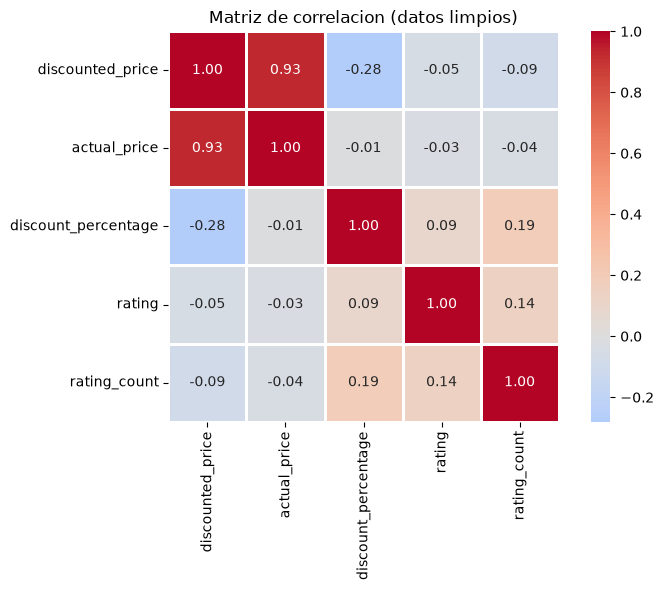

                     discounted_price  actual_price  discount_percentage  \
discounted_price                1.000         0.931               -0.280   
actual_price                    0.931         1.000               -0.006   
discount_percentage            -0.280        -0.006                1.000   
rating                         -0.054        -0.033                0.086   
rating_count                   -0.086        -0.043                0.186   

                     rating  rating_count  
discounted_price     -0.054        -0.086  
actual_price         -0.033        -0.043  
discount_percentage   0.086         0.186  
rating                1.000         0.140  
rating_count          0.140         1.000  


In [19]:
numericas = ["discounted_price", "actual_price", "discount_percentage", "rating", "rating_count"]
matriz = df[numericas].corr()
plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True, linewidths=1)
plt.title("Matriz de correlacion (datos limpios)")
plt.tight_layout(); plt.show()
print(matriz.round(3))

> ✍️ **32.** Identifica la correlación más fuerte y la más débil de la matriz, con sus valores.

> ✍️ **33.** ¿Cuál es la correlación entre `rating` y `actual_price`? ¿Confirma con un número lo que la prueba t sugirió sobre precio y calidad?

> ✍️ **34.** Calcula Pearson y Spearman entre `discount_percentage` y `rating_count` en una celda. ¿Coinciden? ¿Qué relación hay entre descuento y popularidad?


In [20]:
# Celda para la P34
# rp,_ = stats.pearsonr(df["discount_percentage"], df["rating_count"])
# rs,_ = stats.spearmanr(df["discount_percentage"], df["rating_count"])
# print(f"Pearson={rp:.3f}  Spearman={rs:.3f}")


## Paso 11 — Regresión lineal simple y múltiple


In [21]:
# Simple: discounted_price ~ actual_price
X = df[["actual_price"]]
y = df["discounted_price"]
m_simple = LinearRegression().fit(X, y)
r2_simple = m_simple.score(X, y)
print(f"SIMPLE: discounted = {m_simple.intercept_:.1f} + {m_simple.coef_[0]:.4f}*actual   R2={r2_simple:.3f}")

# Multiple: discounted ~ actual + discount_percentage
Xm = df[["actual_price", "discount_percentage"]]
m_mult = LinearRegression().fit(Xm, y)
r2_mult = m_mult.score(Xm, y)
print(f"MULTIPLE: R2={r2_mult:.4f}")
for v, c in zip(["actual_price","discount_percentage"], m_mult.coef_):
    print(f"   {v}: {c:.4f}")

SIMPLE: discounted = -22.3 + 0.5586*actual   R2=0.866
MULTIPLE: R2=0.9416
   actual_price: 0.5576
   discount_percentage: -24.4366


> ✍️ **35.** Interpreta la pendiente del modelo simple. ¿Cuánto sube el precio con descuento por cada rupia de aumento en el precio real?

> ✍️ **36.** ¿El modelo múltiple mejora al simple? Compara R². ¿Por qué agregar `discount_percentage` mejora tanto la predicción del precio final?

> ✍️ **37.** Interpreta el signo del coeficiente de `discount_percentage` en el modelo múltiple. ¿Por qué es negativo?

> ✍️ **38.** Usa el modelo múltiple para predecir el precio con descuento de un producto con `actual_price=2000` y `discount_percentage=40`. Escribe el cálculo.


In [22]:
# Celda para la P38: prediccion con el modelo multiple
# pred = m_mult.predict([[2000, 40]])
# print("Precio con descuento estimado:", round(pred[0], 2))


## Paso 12 — Supuestos del modelo (análisis de residuos)


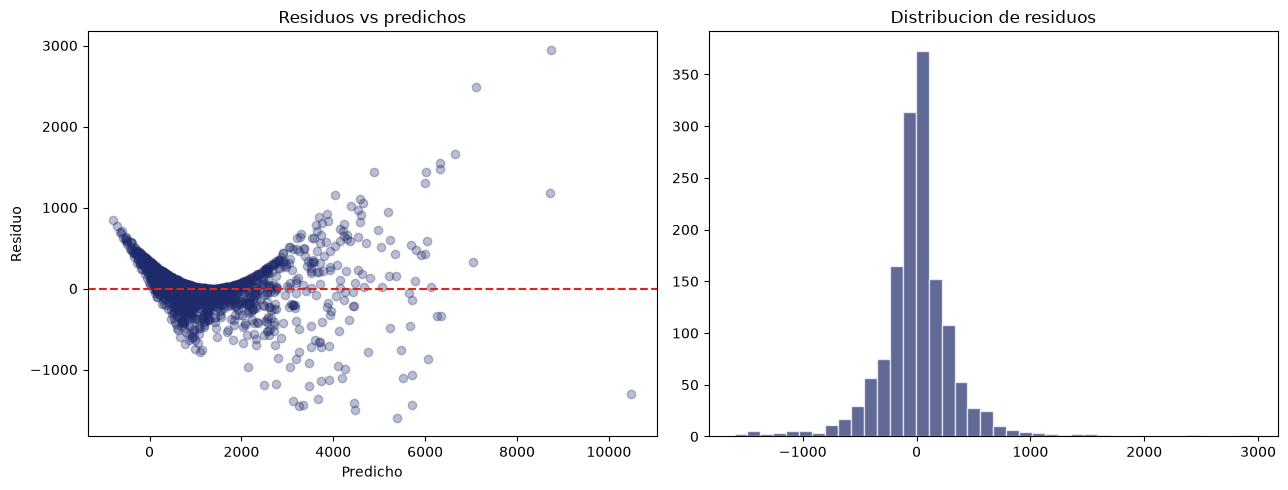

Shapiro-Wilk sobre residuos: p=0.0000


In [23]:
pred = m_mult.predict(Xm)
residuos = y - pred

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(pred, residuos, alpha=0.3, color="#1e2a6b")
axes[0].axhline(0, color="#e2231a", linestyle="--")
axes[0].set_title("Residuos vs predichos"); axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Residuo")
axes[1].hist(residuos, bins=40, color="#1e2a6b", alpha=0.7, edgecolor="white")
axes[1].set_title("Distribucion de residuos")
plt.tight_layout(); plt.show()

# Prueba de normalidad
muestra = pd.Series(residuos).sample(min(500,len(residuos)), random_state=1)
stat, p_sh = stats.shapiro(muestra)
print(f"Shapiro-Wilk sobre residuos: p={p_sh:.4f}")

> ✍️ **39.** **Homocedasticidad:** ¿los residuos vs predichos muestran una nube uniforme o un patrón (embudo)? ¿Qué implicaría un embudo?

> ✍️ **40.** **Normalidad:** ¿el histograma de residuos se parece a una campana? Según Shapiro-Wilk, ¿son perfectamente normales? ¿Invalida esto el modelo?

> ✍️ **41.** Enumera los cuatro supuestos de la regresión lineal y di cómo verificaste (o verificarías) cada uno en esta actividad.


### 🔧 Reto 4 — Modelo predictivo propio

Construye un modelo de regresión múltiple para predecir `rating` usando las variables que elijas. Reporta el R² y decide si el rating es predecible con estas variables.


In [24]:
predictoras = ["actual_price", "discount_percentage", "rating_count"]
m_rating = LinearRegression().fit(df[predictoras], df["rating"])
print("R2:", round(m_rating.score(df[predictoras], df["rating"]), 4))

R2: 0.0241


> ✍️ **42.** Reporta el R² de tu modelo de rating. ¿Es alto o bajo? ¿Qué conclusión sacas sobre la predictibilidad de la calificación a partir de precios y descuentos?


---
# FASE 5 — Síntesis integradora de alto nivel

Estas preguntas exigen conectar TODO el flujo: limpieza + estadística + inferencia + modelado.


> ✍️ **43.** Recorre el pipeline completo que ejecutaste y descríbelo en 5 etapas (carga, limpieza, validación, análisis, modelado). ¿Qué habría pasado con el análisis final si hubieras saltado la fase de limpieza?

> ✍️ **44.** Los outliers de precio, ¿afectaron tu regresión? Reflexiona: si los hubieras eliminado en vez de conservado, ¿cómo cambiaría el modelo `discounted_price ~ actual_price`?

> ✍️ **45.** Integra tres hallazgos: (a) la correlación precio-rating, (b) la prueba t caros vs baratos, y (c) el R² del modelo de rating. ¿Qué historia coherente cuentan los tres juntos sobre "precio y calidad" en Amazon?

> ✍️ **46.** Un directivo pregunta: "¿Puedo subir el precio de mis productos sin dañar sus calificaciones?". Con base en tus resultados, ¿qué le responderías y con qué evidencia estadística?

> ✍️ **47.** El dataset original tenía precios en rupias (₹). Si tu jefe quisiera el análisis en pesos mexicanos, ¿qué transformación de datos añadirías al pipeline y en qué fase?

> ✍️ **48.** **Calidad de datos:** ordena, de mayor a menor impacto, los problemas de calidad que encontraste (duplicados, precios como texto, ratings corruptos, nulos) según cuánto habrían dañado el análisis si no se corregían. Justifica el orden.

> ✍️ **49.** **Reproducibilidad:** ¿por qué es importante que todo tu pipeline de limpieza esté en código (y no hecho a mano en Excel)? Conecta con el concepto de reproducibilidad de la ciencia de datos.

> ✍️ **50 (reflexión final).** Este ejercicio simuló el trabajo real de un científico de datos de principio a fin. ¿Qué fase te resultó más difícil y cuál más reveladora? ¿Cómo aplicarías este pipeline completo en un proyecto de tu carrera de Ingeniería en Computación?


---
## Cierre y entrega

Ejecutaste el flujo completo de un proyecto de ciencia de datos: partiste de datos **crudos y sucios** de Amazon, los **limpiaste y validaste**, y sobre ellos aplicaste **estadística descriptiva, inferencia, pruebas de hipótesis, correlación y regresión con verificación de supuestos**. Este es, en esencia, el trabajo profesional de un data scientist.

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error** (Entorno de ejecución → Ejecutar todo).
2. Confirma que respondiste las **50 preguntas ✍️** y los **4 retos de código**.
3. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Pipeline de limpieza correcto y completo | 20 |
| Retos de código resueltos (4) | 20 |
| Respuestas a las 50 preguntas ✍️ | 40 |
| Análisis integrador de alto nivel (Fase 5) | 15 |
| Orden y documentación | 5 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Dataset: amazon_raw.csv (versión cruda del Amazon Sales Dataset).*


In [26]:
# Resumen numerico para completar las respuestas
cv_precio = df["actual_price"].std() / df["actual_price"].mean()
cv_rating = df["rating"].std() / df["rating"].mean()
ic90 = stats.t.interval(0.90, df=len(df)-1, loc=media_r, scale=ee)
ic99 = stats.t.interval(0.99, df=len(df)-1, loc=media_r, scale=ee)
rp, _ = stats.pearsonr(df["discount_percentage"], df["rating_count"])
rs, _ = stats.spearmanr(df["discount_percentage"], df["rating_count"])
pred_38 = m_mult.predict([[2000, 40]])[0]
ahorro_max = df.loc[df["ahorro"].idxmax()]
print(f"Ahorro promedio: ₹{df['ahorro'].mean():.2f}")
print(f"Mayor ahorro: ₹{ahorro_max['ahorro']:.2f} | producto: {ahorro_max['product_name']}")
print(f"CV precio: {cv_precio:.3f} | CV rating: {cv_rating:.3f}")
print(f"IC90: ({ic90[0]:.3f}, {ic90[1]:.3f})")
print(f"IC99: ({ic99[0]:.3f}, {ic99[1]:.3f})")
print(f"Pearson descuento-rating_count: {rp:.3f}")
print(f"Spearman descuento-rating_count: {rs:.3f}")
print(f"Prediccion P38: ₹{pred_38:.2f}")
print(f"Media descuento rating alto: {alto.mean():.3f} | bajo: {bajo.mean():.3f}")

Ahorro promedio: ₹1154.96
Mayor ahorro: ₹9951.00 | producto: Producto Electronics 880
CV precio: 0.893 | CV rating: 0.068
IC90: (3.992, 4.016)
IC99: (3.985, 4.022)
Pearson descuento-rating_count: 0.186
Spearman descuento-rating_count: 0.170
Prediccion P38: ₹1219.79
Media descuento rating alto: 45.786 | bajo: 44.159


/home/maquiavelico/Documentos/optativa3-ciencia-datos/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Guia de respuestas — actividad de Amazon

## Fase 1 — Diagnostico y limpieza

1. `actual_price`, `discounted_price`, `discount_percentage`, `rating` y `rating_count` aparecen como texto porque contienen simbolos (`₹`, `%`), comas de miles o el valor corrupto `|`.
2. El archivo tiene 1,480 filas y 8 columnas. Hay 15 filas duplicadas y 5 nulos iniciales, todos en `rating_count`. Despues de convertir tipos aparecen 19 nulos en `rating` por los valores `|`.
3. Puede llegar por un error de scraping, una celda mal capturada, un separador interpretado incorrectamente o una edicion manual defectuosa.
4. No correctamente. `actual_price` es texto y `mean()` produciria un `TypeError` porque no se puede calcular la media de cadenas con simbolos y comas.
5. Se eliminaron 15 duplicados. Conviene hacerlo antes para que no dupliquen observaciones ni distorsionen promedios, conteos y modelos.
6. Se quita `₹`, se eliminan las comas de miles y `pd.to_numeric(..., errors="coerce")` convierte a numero; los valores imposibles pasan a `NaN`.
7. El precio real promedio es **₹2,565.81** y el precio con descuento promedio es **₹1,410.85**.
8. `1,128` contiene una coma y no es un literal numerico valido para una conversion directa; Python lo trataria como texto y produciria un `ValueError`.
9. El descuento promedio es **45.09%** y el maximo **85%**. En promedio es un descuento intermedio, no bajo, aunque varia entre productos.
10. Aparecieron **19 nulos** en `rating`; proceden de los 19 valores corruptos `|` convertidos con `errors="coerce"`.
11. Imputaria con la mediana porque son pocos y asi se conservan las filas sin dejar que valores extremos afecten demasiado el reemplazo.
12. La mediana es robusta frente a productos virales con muchisimas reseñas; la media se elevaria artificialmente.
13. Si se cumplen: ratings fuera de rango = 0, descuentos fuera de rango = 0 y precios incoherentes = 0. Validar reglas comprueba la logica del dato, mientras que limpiar formato solo cambia su representacion.
14. Dos reglas posibles: `rating_count >= 0` y `actual_price > 0`; tambien puede exigirse que `discounted_price > 0`.
15. Se detectaron **78 outliers**, equivalentes al **5.3%** de las filas.
16. La distribucion esta sesgada a la derecha: la mayoria de precios es baja o media y hay una cola de precios altos, por eso aparecen muchos outliers superiores.
17. Los conservaria inicialmente: pueden representar productos premium reales. Solo los eliminaria si se confirma que son errores; de lo contrario conviene analizarlos por separado o aplicar una transformacion logaritmica.
18. `ahorro_pct` coincide practicamente con `discount_percentage`. Las diferencias pequenas se deben al redondeo de precios o del porcentaje.
19. El ahorro promedio es **₹1,154.96**. El mayor ahorro es **₹9,951**, correspondiente a `Producto Electronics 880`.

## Fase 2 — Estadistica descriptiva e inferencial

20. En `actual_price`, la media es **₹2,565.81** y la mediana **₹1,856**. La media mayor indica sesgo a la derecha; reportaria la mediana como precio tipico.
21. La desviacion estandar del `rating` es **0.273**. Las calificaciones estan bastante concentradas alrededor de 4.0.
22. `CV_precio = 0.893` y `CV_rating = 0.068`. El precio varia relativamente mucho mas que el rating.
23. El IC95% del rating es **(3.990, 4.018)**. Es estrecho porque la muestra es grande; al aumentar `n`, disminuye el error estandar.
24. IC90%: **(3.992, 4.016)**; IC95%: **(3.990, 4.018)**; IC99%: **(3.985, 4.022)**. De mas estrecho a mas ancho: 90%, 95%, 99%. Mayor confianza exige mayor amplitud.
25. `P(descuento alto) = 0.405` y `P(descuento alto | caro) = 0.428`. Los productos caros tienen una probabilidad ligeramente mayor de descuento alto.
26. Bayes da `P(caro | descuento alto) = 0.265`, igual que el calculo directo. Representa la probabilidad de que un producto sea caro cuando observamos un descuento alto.
27. Son distintas porque condicionan eventos diferentes: una parte de los productos caros tiene descuento alto, mientras que la otra pregunta que parte de los productos con descuento alto es cara.
28. La prueba t da `t=-0.657`, `p=0.5117`; no hay diferencia significativa entre ratings de productos caros y baratos. No se confirma que lo caro sea mejor.
29. H0: la media de rating de productos caros es igual a la de productos baratos. H1: las medias son diferentes.
30. ANOVA: `F=0.532`, `p=0.6605`; no hay diferencias significativas de rating entre las categorias analizadas.
31. El reto da `t=1.995`, `p=0.0462`. Al nivel de 5% la diferencia es significativa: los productos con rating alto tienen descuento medio **45.786%**, frente a **44.159%** en los de rating bajo. Es una diferencia pequena y no demuestra causalidad.

## Fase 4 — Correlacion y regresion

32. La correlacion mas fuerte es `discounted_price` con `actual_price`: **0.931**. La mas debil en valor absoluto es `actual_price` con `discount_percentage`: **-0.006**.
33. La correlacion entre `rating` y `actual_price` es **-0.033**, practicamente nula. Coincide con la prueba t: el precio no parece explicar la calidad percibida.
34. Pearson entre descuento y `rating_count` es **0.186** y Spearman **0.170**. Son parecidas y positivas debiles: un descuento mayor se asocia ligeramente con popularidad, pero no la explica mucho.
35. La pendiente simple es **0.5586**: por cada rupia adicional de precio real, el precio con descuento aumenta aproximadamente 0.559 rupias.
36. Si: el R2 sube de **0.866** a **0.9416**. El porcentaje de descuento aporta informacion directa sobre el precio final.
37. El coeficiente del descuento es **-24.4366**: manteniendo constante el precio real, un punto porcentual adicional de descuento reduce el precio final aproximadamente 24.44 rupias.
38. Para `actual_price=2000` y `discount_percentage=40`, el modelo predice aproximadamente **₹1,219.79**.
39. Se observa un patron de embudo: la dispersion de los residuos aumenta para valores predichos altos. Esto indica heterocedasticidad y hace menos confiables los errores estandar del modelo.
40. El histograma esta centrado pero no es perfectamente normal; Shapiro-Wilk da `p<0.001`. Esto no invalida automaticamente el modelo predictivo, pero limita algunas inferencias y recomienda revisar transformaciones o modelos robustos.
41. Los cuatro supuestos son: linealidad, independencia, homocedasticidad y normalidad de residuos. Se revisan con residuos vs. predichos, conocimiento del muestreo, grafico de residuos y prueba/histograma, respectivamente.
42. El modelo para predecir `rating` obtiene **R2=0.0241**, un valor bajo. Precio, descuento y cantidad de reseñas explican muy poco la variacion del rating.

## Fase 5 — Sintesis

43. El pipeline fue: cargar y auditar; limpiar tipos, duplicados y nulos; validar reglas y outliers; calcular estadistica, probabilidades y pruebas; construir y revisar modelos. Sin limpieza habria errores de conversion, promedios sesgados y conclusiones poco confiables.
44. Los outliers influyen en la pendiente y en los residuos de la regresion. Si fueran errores y se eliminaran, el modelo probablemente seria mas estable; si fueran productos premium reales, eliminarlos ocultaria informacion importante.
45. La correlacion precio-rating es casi nula, la prueba t no es significativa y el R2 del modelo de rating es bajo. En conjunto, el precio no parece ser un buen indicador de calidad.
46. No afirmaria que subir el precio no afectara las calificaciones. Los datos muestran poca relacion entre precio y rating, pero son observacionales; recomendaria un experimento o seguimiento antes de tomar la decision.
47. Añadiria una columna de conversion, por ejemplo `actual_price_mxn = actual_price * tipo_cambio`, despues de limpiar los precios y antes del analisis.
48. Un orden razonable es: precios como texto, porque bloquean calculos; ratings corruptos, porque alteran calidad y pruebas; nulos, porque reducen o sesgan la muestra; duplicados, porque inflan resultados, aunque aqui fueron pocos.
49. El pipeline en codigo es reproducible, auditable y repetible con nuevos datos. Excel dificulta rastrear cambios y puede producir resultados distintos al repetir manualmente el proceso.
50. La fase mas dificil fue integrar limpieza, inferencia y modelado; la mas reveladora fue comprobar que una correlacion fuerte entre precios puede coexistir con una relacion casi nula entre precio y rating. Aplicaria el mismo pipeline a logs, sensores o registros de usuarios.

## Retos de codigo resueltos

```python
# Reto 1
copia = pd.read_csv("amazon_raw - amazon_raw.csv")["discount_percentage"]
copia = pd.to_numeric(copia.astype(str).str.replace("%", "", regex=False), errors="coerce")
print(copia.describe())

# Reto 2
df["ahorro"] = df["actual_price"] - df["discounted_price"]
df["ahorro_pct"] = (df["ahorro"] / df["actual_price"] * 100).round(1)

# Reto 3
alto = df[df["rating"] >= 4]["discount_percentage"]
bajo = df[df["rating"] < 4]["discount_percentage"]
t, p = stats.ttest_ind(alto, bajo, equal_var=False)
print(f"t={t:.3f}, p={p:.4f}")

# Reto 4
predictoras = ["actual_price", "discount_percentage", "rating_count"]
m_rating = LinearRegression().fit(df[predictoras], df["rating"])
print("R2:", round(m_rating.score(df[predictoras], df["rating"]), 4))
```